In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import f2D_utilities as utils;
from matplotlib.animation import FuncAnimation;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_8.0/DN_RECTEST_CULHAM_NVPAR127";
delta_t = reader.fetch_delta_t(directory_path);
data_arrays = reader.fetch_f2D_data(directory_path);

In [3]:
print(data_arrays[0].dims);

('vpar', 'r')


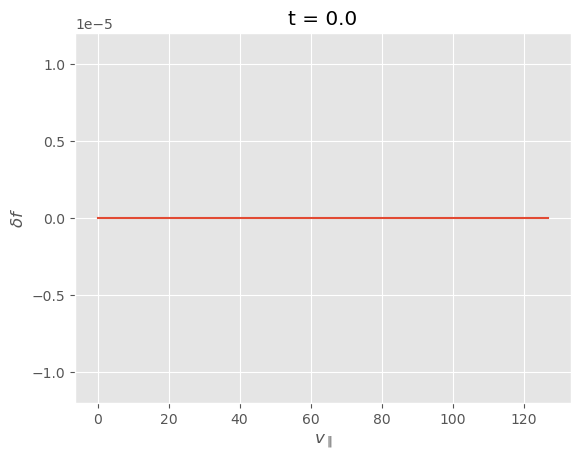

In [ ]:
def animate_velocity(f2D_list, dt_diag, delta_t):

	vpar, delta_f_vpar_time = utils.compute_delta_f_vpar(f2D_list);
	stride = utils.calculate_stride(delta_t, dt_diag);

	fig, ax = plt.subplots()
	line, = ax.plot(vpar, delta_f_vpar_time[0])
	ax.set_ylim(
		-np.max(np.abs(delta_f_vpar_time)),
		np.max(np.abs(delta_f_vpar_time))
	);
	
	ax.set_xlabel(r'$v_\parallel$')
	ax.set_ylabel(r'$\delta f$')
	
	def update(i):
		line.set_ydata(delta_f_vpar_time[i])
		ax.set_title(r"$\delta f$ at time-step {i * stride}")
		return line,
	
	anim = FuncAnimation(
		fig, update, frames=len(delta_f_vpar_time), interval=50
	)
	
	anim.save(
	"f2D_vpar_animation.mp4",
	writer="ffmpeg",
	dpi=150
	);

animate_velocity(data_arrays, dt_diag = 50, delta_t = delta_t);